<style>
.shaded-cell {
    background-color: #f0f4f8 !important;
    padding: 15px !important;
    border-radius: 8px !important;
     border-left: 5px solid #3498db
}
</style>

<h1>🚢 Titanic Survival Probability Analysis </h1>

<h4 style="color:#555; margin-top:-8px;">
Distribution Analysis, Z-Score & Probability Modeling
</h4>

<hr style="border:1px solid #ddd;">


<div style="background-color:#fff9c4; padding:16px; border-radius:8px; border-left:5px solid #fbc02d;">

<h3>📘 Background &Objective</h3>

<h4> Purpose of this analysis</h4>
The objective of this analysis is to understand survival outcomes on the Titanic through probability-based exploratory data analysis (EDA). Rather than immediately applying machine learning, this notebook focuses on:

Identifying key survival drivers

Evaluating statistical reliability

Understanding distributional behavior

Preparing features for downstream predictive modeling

This approach ensures that modeling decisions are data-informed, interpretable, and statistically sound.
</div>


## 🔍 Key Questions Explored

This analysis focuses on understanding passenger survival on the Titanic by addressing the following questions:

### 1️⃣ What does the data look like?
- How are key variables such as **Age** and **Fare** distributed?
- Are the distributions symmetric or skewed?
- Do any variables require transformation before analysis?

### 2️⃣ Are there extreme or unusual values in the data?
- Are there any **statistical outliers** that could distort analysis?
- How do **Z-score** and **IQR-based** methods compare in identifying outliers?
- Should any values be removed or treated differently?

### 3️⃣ What is the overall likelihood of survival?
- What proportion of passengers survived?
- What is the baseline survival probability across the dataset?

### 4️⃣ How does survival probability vary by gender?
- Is survival equally likely for male and female passengers?
- Which gender had a higher likelihood of survival?

### 5️⃣ How does passenger class influence survival?
- Does **passenger class** (as a proxy for socioeconomic status) affect survival?
- Is there a clear survival gradient across first, second, and third class?

### 6️⃣ Does age influence survival outcomes?
- Do children, adults, and seniors have different survival probabilities?
- Were younger passengers more likely to survive?

### 7️⃣ How does fare relate to survival?
- Do higher-paying passengers have higher survival probabilities?
- Are extreme survival rates driven by real patterns or small sample sizes?

### 8️⃣ Are observed survival patterns reliable?
- Do any groups show inflated probabilities due to limited sample sizes?
- How should 100% survival rates be interpreted?

### 9️⃣ Which factors are the strongest drivers of survival?
- Which variables show the largest differences in survival probability?
- Which features should be prioritized for predictive modeling?

### 🔟 Is the dataset ready for predictive modeling?
- Is the data statistically well-behaved after preprocessing?
- Are key predictors clearly identified and justified?


**Competition:** Titanic: Machine Learning from Disaster  
**File Used:** `train.csv`  
**Dataset Source:** Kaggle  
https://www.kaggle.com/competitions/titanic/data


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>  📂
    Dataset Overview </h3>
</div>

**Data Source**
* Titanic passenger dataset (Kaggle)

**Key Variables** 
| Feature    | Description                          |
| ---------- | ------------------------------------ |
| `Survived` | Survival indicator (0 = No, 1 = Yes) |
| `Pclass`   | Passenger class (1st, 2nd, 3rd)      |
| `Sex`      | Passenger gender                     |
| `Age`      | Passenger age                        |
| `Fare`     | Ticket fare                          |
| `SibSp`    | Number of siblings/spouses aboard    |
| `Parch`    | Number of parents/children aboard    |


**Importing the Required Files**

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
from sklearn.calibration import calibration_curve

In [8]:
df = pd.read_csv("train.csv") 
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [12]:
df.head(3) 
df.tail(3)
pd.Series(df.columns).describe()

count              12
unique             12
top       PassengerId
freq                1
dtype: object

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Age data is available for 714 of the 891 passengers, with a mean age of approximately 30 years and a maximum observed age of 80. Fare values range from 0 to 512, indicating the presence of at least one passenger with a zero or missing fare value. Cabin information is only available for 204 out of 891 records and is therefore excluded from further analysis due to high missingness. Based on initial exploratory review, the Name, Ticket, and Passenger ID variables are also removed, as they are unlikely to provide meaningful predictive value in their raw form
</div>


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> 🧹Data Quality & Preparation </h3>
</div>

**Data Types & Validation**
Numeric and categorical features are verified to ensure correct downstream analysis.
Incorrect data types can lead to invalid probability estimates, scaling errors,
and misleading model behavior. Therefore, explicit data type validation is
performed prior to exploratory analysis and feature engineering

**Inspect Current Data Types**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Explicitly Separate Numeric & Categorical Features**

In [15]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns

print("Numeric Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

Numeric Features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


**Validate Numeric Ranges (Catch Silent Errors)**

In [27]:
df[numeric_features].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Validate Categorical Consistency**

In [16]:
for col in categorical_features:
    print(f"\n{col} unique values:")
    print(df[col].value_counts(dropna=False))


Name unique values:
Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64

Sex unique values:
Sex
male      577
female    314
Name: count, dtype: int64

Ticket unique values:
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
37

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Summary:</strong>
Data quality checks are critical to avoid biased probability estimates and
misleading conclusions. Ensuring correct data types prevents numeric operations
from being applied to categorical fields and guarantees that probability
calculations reflect true feature behavior rather than data encoding artifacts.
</div>

**Missing Values**

In [17]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [18]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [19]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip().str.lower()
df_clean.drop(columns=['passengerid', 'ticket', 'cabin', 'name'], inplace=True)
df_clean

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [20]:
df_clean['age'] = df_clean['age'].fillna(df_clean.groupby('sex')['age'].transform('median'))
df_clean['age'].isnull().sum()

np.int64(0)

In [21]:
ports = df_clean['embarked'].dropna().unique().tolist()          # ['S', 'C', 'Q']

df_clean.loc[df_clean['embarked'].isnull(), 'embarked'] = np.random.choice(ports, size=df_clean['embarked'].isnull().sum())
df_clean['embarked'].isna().sum()

np.int64(0)

**Final Quality Check before EDA**

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df_clean.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='object')

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Summary:</strong>
<ul>
  <li>Removed non-informative identifier variables (<code>Name</code>, <code>Ticket</code>, <code>PassengerId</code>)</li>
  <li>Dropped the <code>Cabin</code> feature due to a high proportion of missing values</li>
  <li>Imputed missing <code>Age</code> values using gender-based median imputation</li>
  <li>Addressed missing <code>Embarked</code> values by randomly assigning from existing categories to preserve distribution balance</li>
</ul>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🧠 Feature Engineering </h3>
</div>

Feature engineering is performed to extract additional predictive signal from
existing variables. Rather than relying solely on raw attributes, engineered
features are designed to better reflect social structure, travel context, and
evacuation dynamics observed during the Titanic disaster.


In [24]:
age_bins = [0, 12, 19, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels)
df_clean.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'age_group'],
      dtype='object')

In [25]:
df_clean['fare_group'] = pd.qcut(df_clean['fare'],q=3,labels=['Low', 'Mid', 'High'])
df_clean.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'age_group', 'fare_group'],
      dtype='object')

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>Encoding Categorical Variables </h3>
</div>

Categorical variables must be encoded into numeric representations to enable
statistical analysis and machine learning models. Encoding is performed after
data cleaning and validation to ensure that categories are well-defined and
free of inconsistencies.

One-hot encoding is applied to nominal variables to avoid introducing
artificial ordinal relationships.


In [26]:
le = LabelEncoder()
df_clean['sex_encoded'] = le.fit_transform(df_clean['sex'])
df_clean['embarked_encoded'] = le.fit_transform(df_clean['embarked'])
print("DataFrame after Label Encoding:")
df_clean.head(5)

DataFrame after Label Encoding:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,age_group,fare_group,sex_encoded,embarked_encoded
0,0,3,male,22.0,1,0,7.2500,S,Young Adult,Low,1,2
1,1,1,female,38.0,1,0,71.2833,C,Adult,High,0,0
2,1,3,female,26.0,0,0,7.9250,S,Young Adult,Low,0,2
3,1,1,female,35.0,1,0,53.1000,S,Young Adult,High,0,2
4,0,3,male,35.0,0,0,8.0500,S,Young Adult,Low,1,2


In [27]:
df_clean.drop(columns=['sex', 'embarked'],inplace=True)
df_clean

,survived,pclass,age,sibsp,parch,fare,age_group,fare_group,sex_encoded,embarked_encoded
0,0,3,22.0,1,0,7.2500,Young Adult,Low,1,2
1,1,1,38.0,1,0,71.2833,Adult,High,0,0
2,1,3,26.0,0,0,7.9250,Young Adult,Low,0,2
3,1,1,35.0,1,0,53.1000,Young Adult,High,0,2
4,0,3,35.0,0,0,8.0500,Young Adult,Low,1,2
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,Young Adult,Mid,1,2
887,1,1,19.0,0,0,30.0000,Teen,High,0,2
888,0,3,27.0,1,2,23.4500,Young Adult,Mid,0,2
889,1,1,26.0,0,0,30.0000,Young Adult,High,1,0


In [28]:
df_clean.rename(columns={'sex_encoded': 'sex','embarked_encoded':'embarked'}, inplace=True)
df_clean

,survived,pclass,age,sibsp,parch,fare,age_group,fare_group,sex,embarked
0,0,3,22.0,1,0,7.2500,Young Adult,Low,1,2
1,1,1,38.0,1,0,71.2833,Adult,High,0,0
2,1,3,26.0,0,0,7.9250,Young Adult,Low,0,2
3,1,1,35.0,1,0,53.1000,Young Adult,High,0,2
4,0,3,35.0,0,0,8.0500,Young Adult,Low,1,2
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,Young Adult,Mid,1,2
887,1,1,19.0,0,0,30.0000,Teen,High,0,2
888,0,3,27.0,1,2,23.4500,Young Adult,Mid,0,2
889,1,1,26.0,0,0,30.0000,Young Adult,High,1,0


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> 
🔍 Exploratory Data Analysis (EDA)</h3>
</div>

**Survival Distribution**

In [29]:
df_clean['survived'].value_counts(normalize=True)
df_clean['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64


<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Analysis: </strong> 
Overall survival probability establishes a baseline against which all feature-level effects are compared.
</div>


**Age & Fare Distribution Analysis**

In [30]:
df_clean[['age', 'fare']].describe()

,age,fare
count,891.000000,891.000000
mean,29.441268,32.204208
std,13.018747,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,29.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


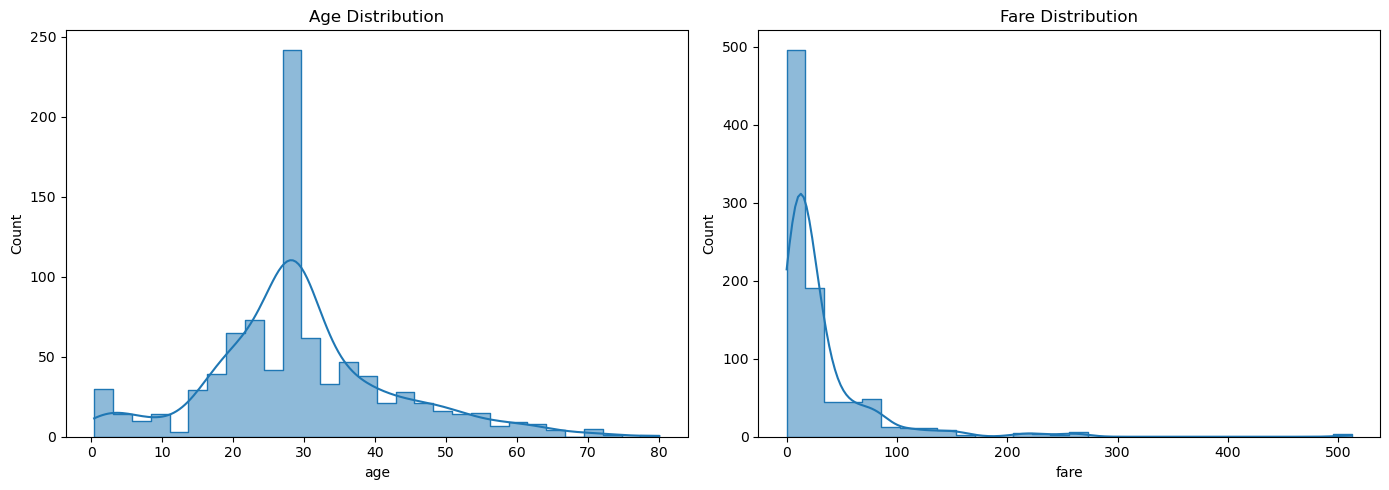

In [31]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
sns.histplot(data=df_clean,x='age',bins=30,kde=True,element='step',ax=ax1)
ax1.set_title('Age Distribution')
sns.histplot(data=df_clean,x='fare',bins=30,kde=True,element='step',ax=ax2)
ax2.set_title('Fare Distribution')
plt.tight_layout()   
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
The age distribution is slightly right-skewed, with most passengers clustered between their mid-20s and mid-30s, and fewer observations at the higher age ranges. The fare distribution is heavily right-skewed, indicating that most passengers paid lower fares, while a small number paid significantly higher amounts, creating long-tail outliers.
</div>

**Sex, Pclass and Embarked Distribution Analysis**

In [32]:
for col in ['sex', 'pclass', 'embarked']:
    print(df_clean[col].value_counts())

sex
1    577
0    314
Name: count, dtype: int64
pclass
3    491
1    216
2    184
Name: count, dtype: int64
embarked
2    644
0    169
1     78
Name: count, dtype: int64


**Survival by Gender**

In [33]:
df_clean.groupby('sex')['survived'].mean()
df_clean.groupby('sex')['survived'].agg(['mean','count'])

,mean,count
sex,,
0,0.742038,314
1,0.188908,577


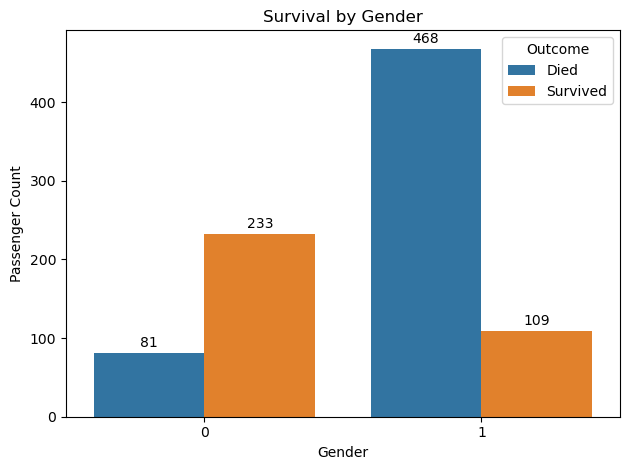

In [34]:
ax = sns.countplot(x='sex',hue='survived',data=df_clean)
ax.set_title("Survival by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Passenger Count")
for container in ax.containers:
    ax.bar_label(container, padding=2)
ax.legend(title='Outcome', labels=['Died', 'Survived'])
plt.tight_layout()    
plt.show()

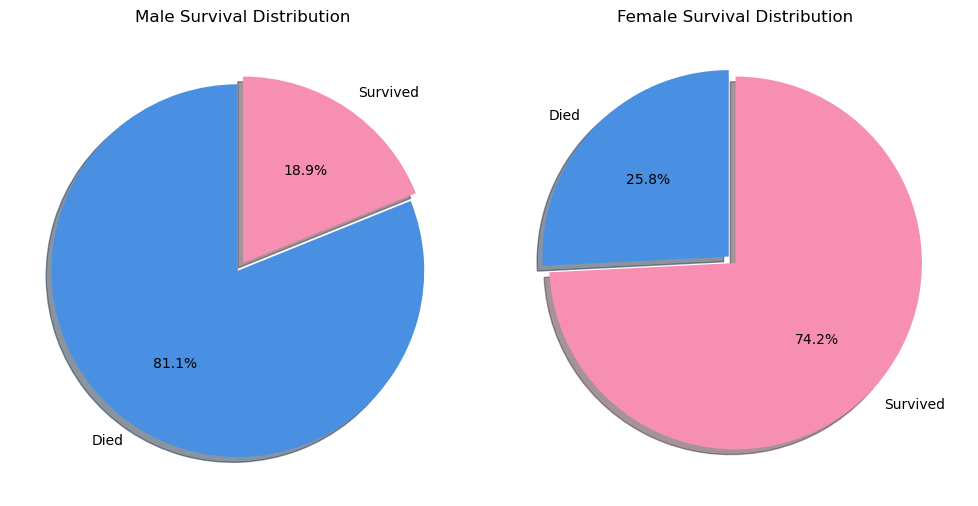

In [35]:
colors = ['#4a90e2', '#f78fb3']  # blue, pink
labels = ['Died', 'Survived']
male_counts = (df.loc[df['Sex'] == 'male', 'Survived'].value_counts().reindex([0, 1], fill_value=0))
female_counts = (df.loc[df['Sex'] == 'female', 'Survived'].value_counts().reindex([0, 1], fill_value=0))
#colors = ['#ff9999', '#66b3ff']   # red-ish / blue-ish
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# Male
axes[0].pie(male_counts.values,labels=labels,autopct='%1.1f%%',startangle=90,colors=colors,shadow=True,explode=[0.05, 0])
axes[0].set_title('Male Survival Distribution')
# Female
axes[1].pie(female_counts.values,labels=labels,autopct='%1.1f%%',startangle=90,colors=colors,shadow=True,explode=[0.05, 0])
axes[1].set_title('Female Survival Distribution')

plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
It is striking to observe that the survival rate among females was dramatically higher than that of males. This strongly suggests that evacuation efforts prioritized women during the disaster.
</div>

**Survival by Passenger Class**

In [36]:
df_clean.groupby('pclass')['survived'].agg(['mean','count'])

,mean,count
pclass,,
1,0.629630,216
2,0.472826,184
3,0.242363,491


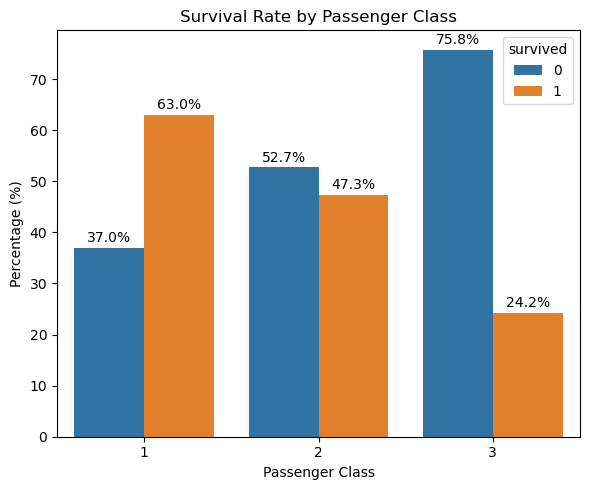

In [37]:
plt.figure(figsize=(6, 5))

counts = ( df_clean.groupby(['pclass', 'survived']).size().reset_index(name='count'))
counts['percent'] = (counts['count'] / counts.groupby('pclass')['count'].transform('sum') * 100)


ax = sns.barplot(x='pclass', y='percent', hue='survived',data=counts)
ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Percentage (%)")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Passengers traveling in first class were more likely to survive than those in lower classes, likely reflecting preferential access to evacuation resources</div>

**Survival by Age Group**

In [38]:
df_clean.groupby('age_group',observed=True)['survived'].agg(['mean','count'])

,mean,count
age_group,,
Child,0.579710,69
Teen,0.410526,95
Young Adult,0.352941,510
Adult,0.400000,195
Senior,0.227273,22


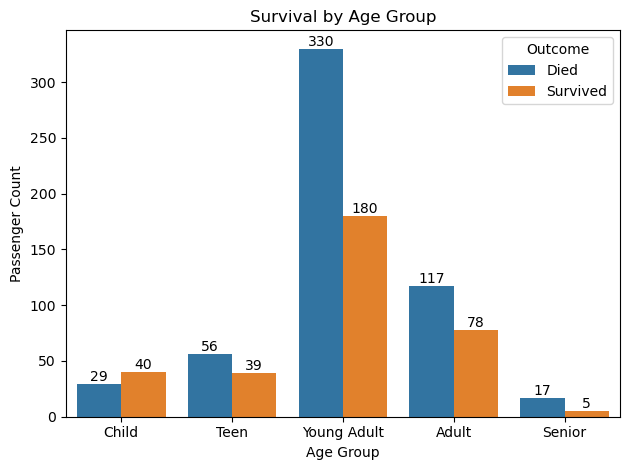

In [39]:
ax = sns.countplot(x='age_group',hue='survived',data=df_clean) 
plt.title('Survival by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Passenger Count')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()    
plt.legend(title='Outcome', labels=['Died', 'Survived'])
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Survival probability varies significantly by age. Children show higher survival rates, while older passengers have lower survival, which makes age an important predictive feature versus a global median
</div>

**Survival by Fare Group**

In [40]:
df_clean.groupby('fare_group',observed=True)['survived'].agg(['mean','count'])


,mean,count
fare_group,,
Low,0.198052,308
Mid,0.402778,288
High,0.559322,295


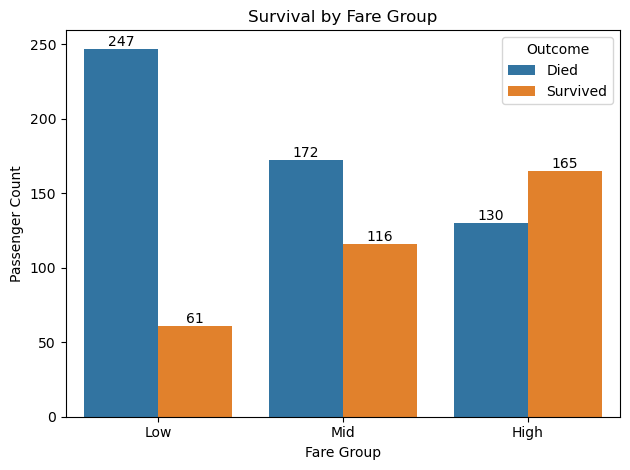

In [41]:
ax = sns.countplot(x='fare_group',hue='survived',data=df_clean) 
plt.title('Survival by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Passenger Count')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()    
plt.legend(title='Outcome', labels=['Died', 'Survived'])
plt.show()

**Survival by Gender x Class**

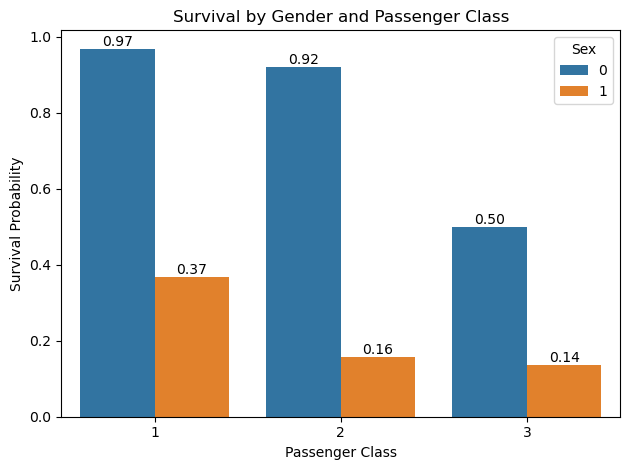

In [42]:
ax = sns.barplot( data=df_clean,x='pclass',y='survived',hue='sex',estimator='mean',errorbar=None)
plt.title('Survival by Gender and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Probability')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()


<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Survival probability varies strongly by both gender and passenger class. Female passengers consistently show substantially higher survival rates than males across all classes, with near-universal survival in first class and a noticeable decline in third class. In contrast, male survival probabilities remain low across all classes, decreasing further with lower passenger class. This pattern highlights the combined influence of gender-based evacuation priority and socioeconomic status on survival outcomes </div>

**Distribution Comparision by Survival Outcome**

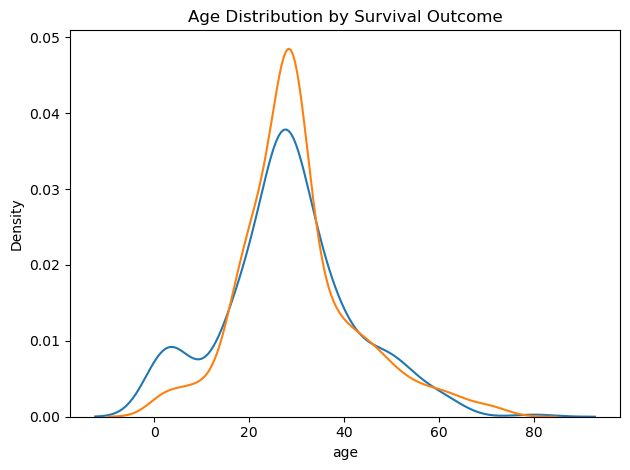

In [43]:
plt.title('Age Distribution by Survival Outcome')
sns.kdeplot(df_clean[df_clean['survived']==1]['age'], label='Survived')
sns.kdeplot(df_clean[df_clean['survived']==0]['age'], label='Did Not Survive')
plt.tight_layout()
plt.show()


<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
The age distributions of survivors and non-survivors overlap substantially, indicating that age alone is not a strong standalone predictor of survival; however, survivors show a slightly higher density at younger ages, suggesting that younger passengers had a modest survival advantage.
</div>

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>EDA Summary:</strong>

Exploratory analysis shows that survival on the Titanic was not random.
Gender and passenger class were the strongest predictors, while age and fare
exhibited nonlinear effects. These findings directly inform feature selection, encoding strategy,
and model choice.

</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> 📊Distribution Analysis & Outliers</h3>
</div>

Age distribution was previously examined during EDA. In this section, the focus
is on identifying outliers and assessing implications for scaling and modeling.


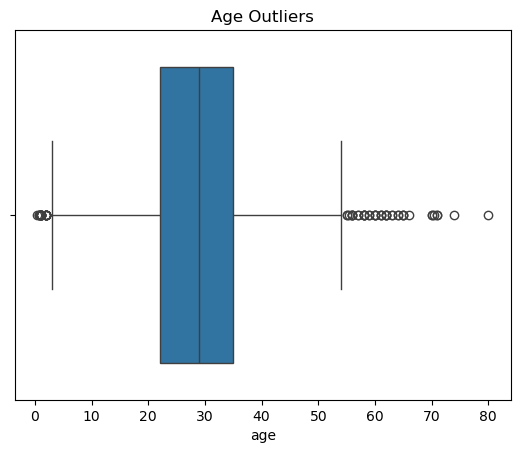

In [44]:
sns.boxplot(x=df_clean['age'])
plt.title('Age Outliers')
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Age outliers are present at both the lower and upper extremes. These values
represent legitimate passenger groups rather than data errors and are retained.
Given the near-normal distribution, age is suitable for standard scaling.
</div>

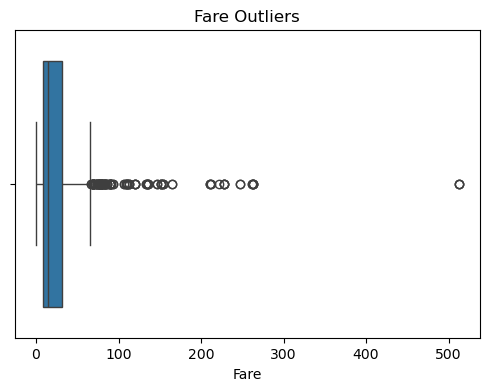

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])
plt.title('Fare Outliers')
plt.xlabel('Fare')
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Fare exhibits significant right-skew with several high-end outliers. These values
represent legitimate ticket prices rather than data errors and are retained.
However, the skewness and extreme values indicate that fare should be scaled or
transformed prior to modeling to prevent dominance in distance-based algorithms.
</div>

In [50]:
cols = ['age','fare']
df_clean[cols].skew()


age     0.491821
fare    4.787317
dtype: float64

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
This data supports what we see in the graph: age is largely centered around the mean, while fare shows much greater variation.
</div>

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Boxplots reveal several IQR-based outliers in both Age and Fare, indicating moderate deviations from the central distribution. However, no observations exceed the ±3 Z-score threshold, suggesting the absence of extreme outliers. This highlights the difference between IQR-based and Z-score-based outlier detection, with IQR being more sensitive to skewed distributions.
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>Feature Scaling & Transformation (Age & Fare)</h3>
</div>


Age and Fare were selected for focused analysis due to their strong relationship
with survival outcomes and differing distributional characteristics. Age
exhibits a near-normal distribution, while Fare is highly right-skewed with
extreme outliers, making them ideal candidates for comparing scaling strategies.


**Z score Standardizaiton**

In [51]:
df_clean.columns
df_zscore = df_clean[['age', 'fare']].copy()

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Technical Note:</strong> 
From earlier analysis, I noticed that the age data is approximatley normal where as fare is skewed. So the purpose of this analysis, scaling the fare so that we have a better comparision.
</div>


In [52]:
df_zscore['fare_log'] = np.log1p(df_zscore['fare'])

In [53]:
df_zscore['age_z'] = stats.zscore(df_zscore['age'], nan_policy='omit')
df_zscore['fare_z'] = stats.zscore(df_zscore['fare_log'], nan_policy='omit')
df_zscore

,age,fare,fare_log,age_z,fare_z
0,22.0,7.2500,2.110213,-0.571902,-0.879741
1,38.0,71.2833,4.280593,0.657785,1.361220
2,26.0,7.9250,2.188856,-0.264480,-0.798540
3,35.0,53.1000,3.990834,0.427219,1.062038
4,35.0,8.0500,2.202765,0.427219,-0.784179
...,...,...,...,...,...
886,27.0,13.0000,2.639057,-0.187625,-0.333698
887,19.0,30.0000,3.433987,-0.802468,0.487082
888,27.0,23.4500,3.196630,-0.187625,0.242007
889,26.0,30.0000,3.433987,-0.264480,0.487082


In [54]:
#Outlier Flags (|Z| > threshold) 
threshold = 3
df_outliers = df_zscore.copy()
df_outliers['age_outlier'] = df_zscore['age_z'].abs() > threshold
df_outliers['fare_outlier'] = df_zscore['fare_z'].abs() > threshold
df_outliers['any_outlier'] = df_outliers[['age_outlier', 'fare_outlier']].any(axis=1)

In [55]:
print(f"Age outliers               : {df_outliers['age_outlier'].sum()}")
print(f"Fare outliers              : {df_outliers['fare_outlier'].sum()}")
print(f"Total outliers (Age & Fare): {df_outliers['any_outlier'].sum()}")

Age outliers               : 7
Fare outliers              : 18
Total outliers (Age & Fare): 25


In [56]:
df_no_outliers = df_zscore.loc[~df_outliers['any_outlier']].copy()
print(f"\nRows before: {len(df_outliers)} | Rows after removing outliers: {len(df_no_outliers)}")
df_no_outliers.columns


Rows before: 891 | Rows after removing outliers: 866


Index(['age', 'fare', 'fare_log', 'age_z', 'fare_z'], dtype='object')

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Survival probability varies significantly by age. Children show higher survival rates, while older passengers have lower survival, which makes age an important predictive feature versus a global median
</div>

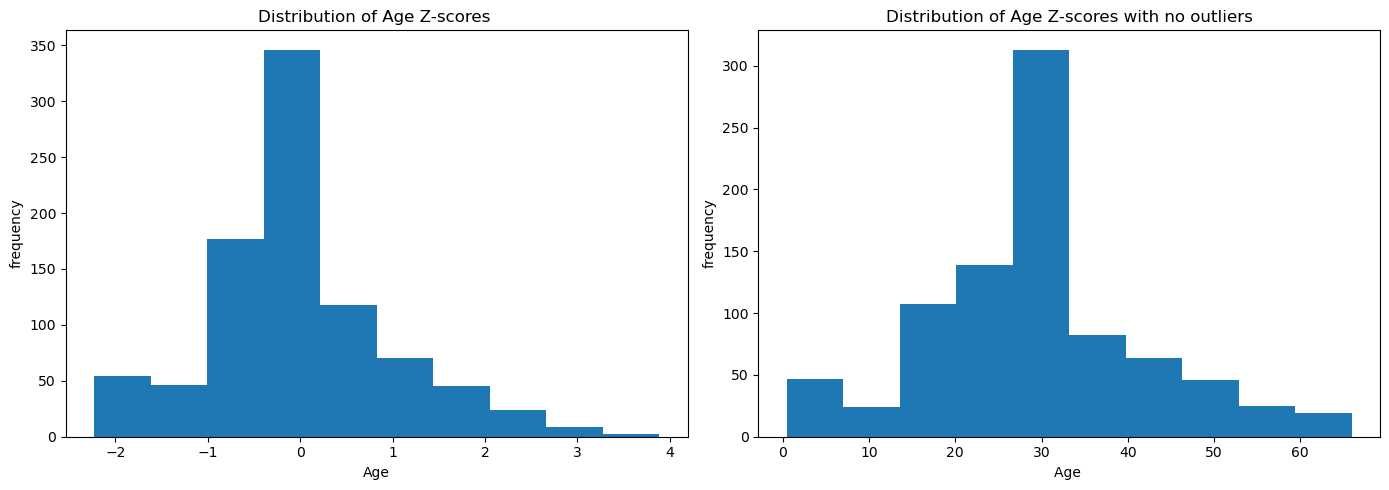

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.hist(df_zscore['age_z'])
ax1.set_title('Distribution of Age Z-scores ')
ax1.set_xlabel('Age')
ax1.set_ylabel('frequency')
ax2.hist(df_no_outliers['age'])
ax2.set_title('Fare Distribution')
ax2.set_title('Distribution of Age Z-scores with no outliers')
ax2.set_xlabel('Age ')
ax2.set_ylabel('frequency')
plt.tight_layout()
plt.show()


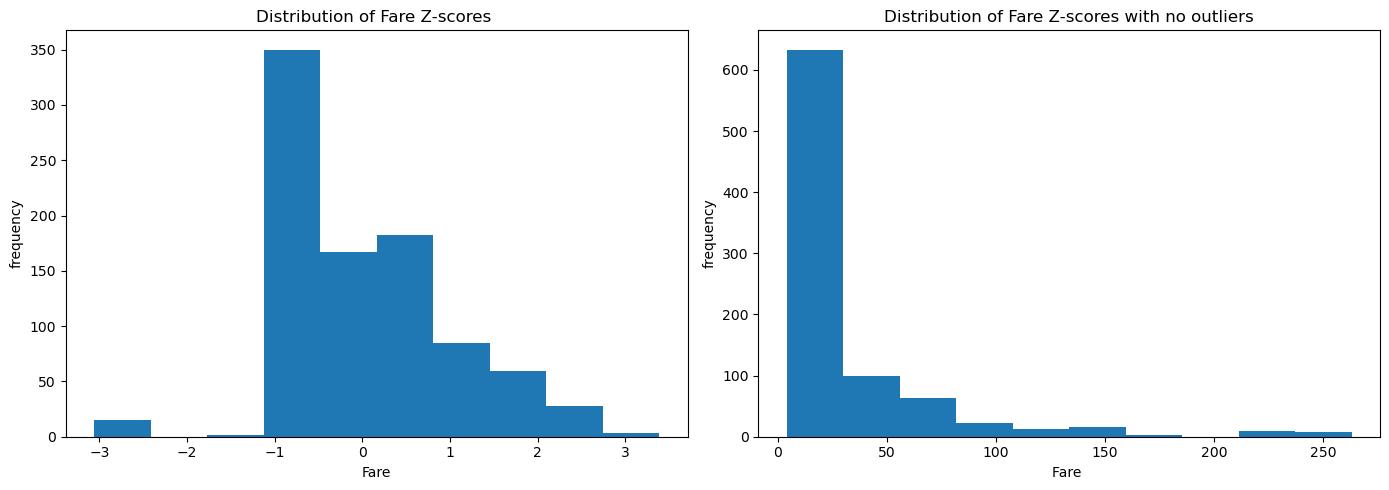

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.hist(df_zscore['fare_z'])
ax1.set_title('Distribution of Fare Z-scores ')
ax1.set_xlabel('Fare')
ax1.set_ylabel('frequency')
ax2.hist(df_no_outliers['fare'])
ax2.set_title('Fare Distribution')
ax2.set_title('Distribution of Fare Z-scores with no outliers')
ax2.set_xlabel('Fare ')
ax2.set_ylabel('frequency')
plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Using a Z-score threshold of ±3, no observations were identified as extreme outliers. This suggests that after preprocessing, the numeric features are well-distributed and do not contain values that are statistically distant from the mean. For skewed variables such as Fare, alternative methods
like IQR may be more appropriate for detecting moderate outliers    </div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Probability analysis</h3>
</div>


Probability analysis quantifies how survival likelihood changes across ranges
of Age and Fare. This step translates exploratory patterns into measurable
probabilities and validates whether observed trends are statistically
meaningful prior to modeling.


In [59]:
overall_survival_prob = df_clean['survived'].mean()
overall_survival_prob

np.float64(0.3838383838383838)

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong> Overall Survival Probabiity: </strong>
The overall survival probability of passenger was 38% .</div>

In [60]:
survival_by_sex = df_clean.groupby('sex')['survived'].mean()
survival_by_sex

sex
0    0.742038
1    0.188908
Name: survived, dtype: float64

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong> Which gender had higher chance of probability? </strong>
Females had a much higher probability of survival than males.</div>

In [61]:
survival_by_class = df_clean.groupby('pclass')['survived'].mean()
survival_by_class

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong> Observation:</strong>
First class passengers had the highest survival probability</div>

In [62]:
survival_by_age_group = df_clean.groupby('age_group',observed=True)['survived'].mean()
survival_by_age_group

age_group
Child          0.579710
Teen           0.410526
Young Adult    0.352941
Adult          0.400000
Senior         0.227273
Name: survived, dtype: float64

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong> Survival Probability by Age Group:</strong>
First class passengers had the highest survival probability</div>

In [63]:
survival_by_fare = (df_clean.groupby('fare_group', observed=True)['survived'].mean())
survival_by_fare

fare_group
Low     0.198052
Mid     0.402778
High    0.559322
Name: survived, dtype: float64

In [64]:
def to_percent(series, decimals=2):
    return round((series * 100),decimals)
df_clean.head(5)

,survived,pclass,age,sibsp,parch,fare,age_group,fare_group,sex,embarked
0,0,3,22.0,1,0,7.2500,Young Adult,Low,1,2
1,1,1,38.0,1,0,71.2833,Adult,High,0,0
2,1,3,26.0,0,0,7.9250,Young Adult,Low,0,2
3,1,1,35.0,1,0,53.1000,Young Adult,High,0,2
4,0,3,35.0,0,0,8.0500,Young Adult,Low,1,2


In [65]:
gender_df = pd.DataFrame({
    'Feature': 'Gender',
    'Group': ['Female', 'Male'],
    'Survival_Probability': [survival_by_sex.iloc[0],survival_by_sex.iloc[1]],
    'Count': [df_clean[df_clean['sex'] == 'female'].shape[0],df_clean[df_clean['sex'] == 'male'].shape[0]]
})
gender_df
#df_clean.head(5)
class_df = pd.DataFrame({
    'Feature': 'Passenger Class',
    'Group': ['First', 'Second','Third'],
    'Survival_Probability': [survival_by_class.iloc[0],survival_by_class.iloc[1],survival_by_class.iloc[2]],
    'Count': [df_clean[df_clean['pclass'] == 1].shape[0],df_clean[df_clean['pclass'] == 2].shape[0],df_clean[df_clean['pclass'] == 3].shape[0]]
})
class_df
age_df = pd.DataFrame({
    'Feature': 'Age Group',
    'Group': list(survival_by_age_group.keys()),
    'Survival_Probability': survival_by_age_group.values,
    'Count': [
        df_clean[df_clean['age_group'] == group].shape[0]
        for group in survival_by_age_group.keys()
    ]
})
age_df
fare_df = pd.DataFrame({
    'Feature': 'Fare Group',
    'Group': survival_by_fare.index.tolist(),
    'Survival_Probability': survival_by_fare.values,
    'Count': (
        df_clean['fare_group']
        .value_counts()
        .reindex(survival_by_fare.index)
        .values
    )
})
fare_df
final_probability_df = pd.concat(
    [gender_df, class_df, age_df, fare_df],
    ignore_index=True
)
final_probability_df['Survival_Probability %'] = (final_probability_df['Survival_Probability'] * 100).round(2)

final_probability_df



,Feature,Group,Survival_Probability,Count,Survival_Probability %
0,Gender,Female,0.742038,0,74.20
1,Gender,Male,0.188908,0,18.89
2,Passenger Class,First,0.629630,216,62.96
3,Passenger Class,Second,0.472826,184,47.28
4,Passenger Class,Third,0.242363,491,24.24
5,Age Group,Child,0.579710,69,57.97
6,Age Group,Teen,0.410526,95,41.05
7,Age Group,Young Adult,0.352941,510,35.29
8,Age Group,Adult,0.400000,195,40.00
9,Age Group,Senior,0.227273,22,22.73


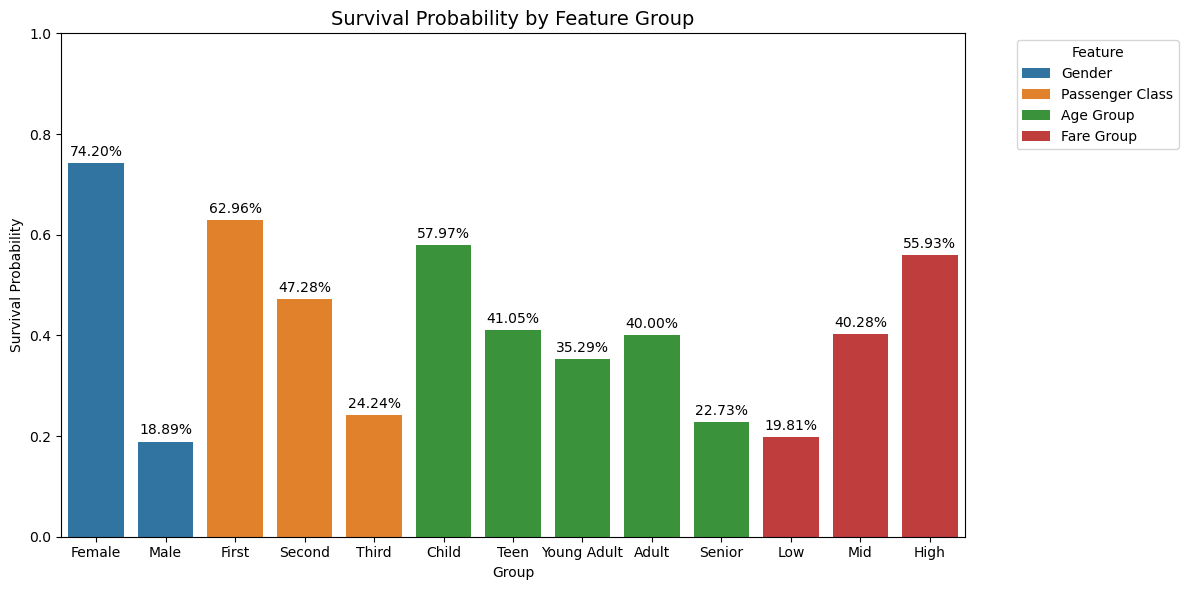

In [66]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=final_probability_df,
    x='Group',
    y='Survival_Probability',
    hue='Feature'
)

ax.set_title('Survival Probability by Feature Group', fontsize=14)
ax.set_xlabel('Group')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1)

# Optional: label probabilities
for container in ax.containers:
    ax.bar_label(container,labels=[f"{v*100:.2f}%" for v in container.datavalues],padding=3)

plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Survival probabilities vary systema
    tically across Age and Fare groups. Younger
passengers and those paying higher fares experienced higher survival likelihood.
These quantified probability patterns reinforce insights from EDA and provide a
strong empirical foundation for downstream logistic regression modelin</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Logistic Regression: Survival Modeling </h3></div>

Following probability-based analysis, a baseline logistic regression model is
trained to quantify the relationship between Age and Fare and survival outcome.
The objective is interpretability rather than maximum predictive performance.


In [85]:
df_scaled = df_zscore.copy()
X = df_scaled[['age', 'fare']].copy()
y = df_clean['survived'].copy()
X,y

(      age     fare
 0    22.0   7.2500
 1    38.0  71.2833
 2    26.0   7.9250
 3    35.0  53.1000
 4    35.0   8.0500
 ..    ...      ...
 886  27.0  13.0000
 887  19.0  30.0000
 888  27.0  23.4500
 889  26.0  30.0000
 890  32.0   7.7500
 
 [891 rows x 2 columns],
 0      0
 1      1
 2      1
 3      1
 4      0
       ..
 886    0
 887    1
 888    0
 889    1
 890    0
 Name: survived, Length: 891, dtype: int64)

**Train / Test Split**

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**Fit Logistic Regression**

In [86]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


**Prediction & Probabilities**

In [87]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]


**Evaluation Metrics**

In [122]:
results_df = X_test.copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred
results_df['Predicted_Probability'] = y_prob
results_df['Correct_Prediction'] = results_df['Actual'] == results_df['Predicted']
results_df.head()

,age,fare,Actual,Predicted,Predicted_Probability,Correct_Prediction
565,24.0,24.1500,0,0,0.382102,True
160,44.0,16.1000,0,0,0.261686,True
553,22.0,7.2250,1,0,0.320820,False
860,41.0,14.1083,0,0,0.266514,True
241,27.0,15.5000,1,0,0.331688,False


In [124]:
correct = results_df['Correct_Prediction'].sum()
incorrect = (results_df['Correct_Prediction'] == False).sum()
correct_incorrect_df = pd.DataFrame({'Prediction_Outcome': ['Correct', 'Incorrect'],'Count': [correct,incorrect]})
correct_incorrect_df

,Prediction_Outcome,Count
0,Correct,109
1,Incorrect,70


In [111]:
accuracy_ratio = results_df['Correct_Prediction'].mean()
accuracy_ratio

np.float64(0.6089385474860335)



<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Out of 179 test observations, the model correctly predicted 109 outcomes and
misclassified 70. This corresponds to an overall accuracy of approximately 61%.
While the model demonstrates predictive signal, the proportion of incorrect
predictions highlights the limitations of using Age and Fare alone to model
survival outcomes.
</div>


In [107]:
TP = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 1)]
TN = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 0)]
FP = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1)]
FN = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]
tp_count = len(TP)
tn_count = len(TN)
fp_count = len(FP)
fn_count = len(FN)

tp_count, tn_count, fp_count, fn_count

(13, 96, 14, 56)

In [108]:
tp = ((results_df['Actual'] == 1) & (results_df['Predicted'] == 1)).sum()
fp = ((results_df['Actual'] == 0) & (results_df['Predicted'] == 1)).sum()

precision = tp / (tp + fp)
precision

np.float64(0.48148148148148145)

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
The model achieves a precision of 0.48, indicating that approximately 48% of passengers predicted to survive actually survived. This result reflects the limitations of the current feature set. To improve precision, the model should be refined and additional predictive features—such as gender, passenger class, and family context—should be incorporated.

</div>

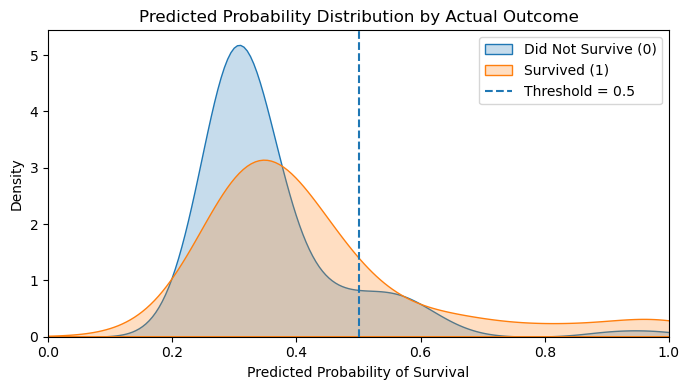

In [145]:
plt.figure(figsize=(7,4))
sns.kdeplot(y_prob[y_test == 0], label='Did Not Survive (0)', fill=True)
sns.kdeplot(y_prob[y_test == 1], label='Survived (1)', fill=True)
# Decision threshold
plt.axvline(0.5, linestyle='--', label='Threshold = 0.5')
plt.title('Predicted Probability Distribution by Actual Outcome')
plt.xlabel('Predicted Probability of Survival')
plt.ylabel('Density')
plt.xlim(0, 1)  # keep probabilities in valid range
plt.legend()
plt.tight_layout()
plt.show()

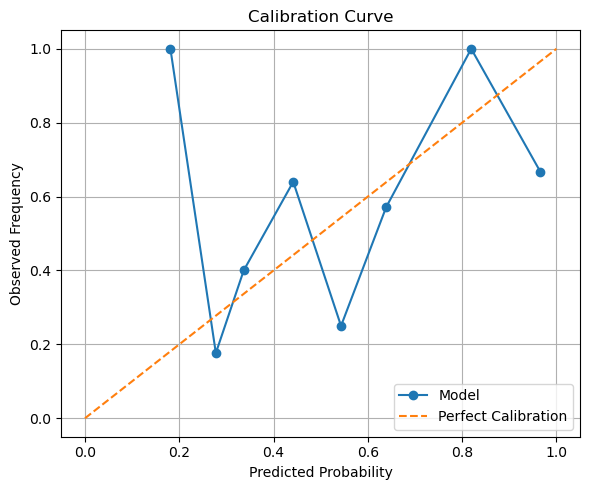

In [143]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')
plt.title('Calibration Curve')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
The calibration curve indicates that predicted probabilities are not well aligned
with observed survival frequencies, particularly in the mid-probability range.
This suggests that the model is both over- and under-confident depending on the
region, reflecting the limited explanatory power of Age and Fare alone.
</div>

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
The predicted probability distributions for survivors and non-survivors show
substantial overlap, particularly in the mid-probability range. While survivors
tend to receive slightly higher predicted probabilities, the lack of clear
separation explains the model’s moderate precision and highlights the limited
discriminatory power of using Age and Fare alone.
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Final Summary</h3></div>

This analysis examined passenger survival on the Titanic using a structured analytical approach, progressing from data exploration to statistical validation and probability-based insights.

<strong> Exploratory Data Analysis & Distribution Review </strong>

Initial distribution analysis showed that Age is approximately normally distributed, while Fare is highly right-skewed. This justified the use of different preprocessing strategies: direct Z-score standardization for Age and transformation-aware approaches for Fare. Boxplots and histograms revealed natural variability in the data without obvious data quality issues.

<strong> Outlier Detection </strong>

Z-score analysis with a conservative threshold of ±3 identified no extreme outliers, indicating that the dataset does not contain anomalous values far from the mean after preprocessing. However, IQR-based analysis revealed moderate outliers, particularly in Fare, which is expected for skewed financial data. This distinction highlights the importance of choosing outlier detection methods appropriate to the underlying distribution.

<strong> Probability Analysis </strong>
<ul>
  <li>Probability analysis quantified survival likelihood and demonstrated that survival outcomes were not random.</li>
  <li>The overall survival probability was relatively low, establishing a clear baseline risk.</li>
  <li>Gender emerged as the strongest predictor, with female passengers having a substantially higher survival probability than male passengers.</li>
  <li>Passenger class showed a clear socioeconomic gradient, with first-class passengers exhibiting the highest survival rates, followed by second and third class.</li>
  <li>Age group analysis indicated higher survival probabilities among children, consistent with evacuation prioritization.</li>
  <li>Fare-based analysis reinforced socioeconomic effects, as higher fare groups were associated with higher survival probabilities.</li>
  <li>A 100% survival rate observed in the highest fare group was driven by a very small sample size, highlighting the importance of evaluating support counts (N) alongside probabilities to avoid misleading interpretations.</li>
</ul>
<strong> Visualization & Interpretation </strong>

Targeted visualizations (survival probability by gender, passenger class, and fare group) made these relationships immediately interpretable. Annotated bar charts reinforced the magnitude of differences across groups and supported the probability findings.

<strong>Conclusion </strong>

Overall, the analysis shows that survival on the Titanic was driven primarily by demographic and socioeconomic factors, particularly gender and passenger class, with age and fare providing additional explanatory power. The dataset is well-behaved statistically, requiring no aggressive outlier removal, and the findings provide strong justification for selecting these variables in downstream predictive modeling such as logistic regression.